<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/Fuzzy_2_input_1_output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Fuzzy 2 input 1 output

Coba2

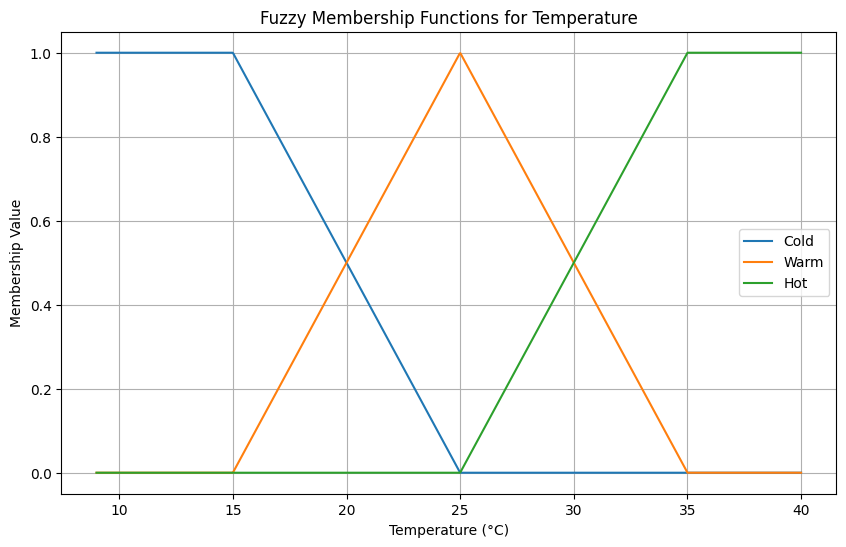

------contoh 1--------
Suhu input crisp:27
Fuzzy Temperature Input:
[0.  0.8 0.2]
Rule Fuzzy Degree:
[0.  0.8 0.2]
Crisp Output:
40.0
------contoh 2--------
Fuzzy Area:
[1 0]
Fuzzy Power:
[0. 1.]
Crisp Output:
100000.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def triangle(x, a, b, c, d, e):
    if x <= a:
        return d
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return (c - x) / (c - b)
    elif x > c:
        return e
    else:
        return 0

def fuzifikasi_suhu(suhu):
    cold = triangle(suhu, 15, 15, 25, 1, 0)
    warm = triangle(suhu, 15, 25, 35, 0, 0)
    hot = triangle(suhu, 25, 35, 35, 0, 1)
    return np.array([cold, warm, hot])

suhu_crisp = 10.0
fuzifikasi_suhu(suhu_crisp)

semua_suhu = np.linspace(9, 40, 1000)
semua_FD_fuzzy_suhu = np.zeros((len(semua_suhu), 3))

for i, val in enumerate(semua_suhu):
    semua_FD_fuzzy_suhu[i] = fuzifikasi_suhu(val)

plt.figure(figsize=(10, 6))
plt.plot(semua_suhu, semua_FD_fuzzy_suhu)
plt.title("Fuzzy Membership Functions for Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Membership Value")
plt.legend(["Cold", "Warm", "Hot"])
plt.grid(True)
plt.show()

suhu_crisp = 27
fuzzy_suhu_input = fuzifikasi_suhu(suhu_crisp)
print("------contoh 1--------\nSuhu input crisp:" + str(suhu_crisp))
print("Fuzzy Temperature Input:")
print(fuzzy_suhu_input)

fuzzy_singleton_PWM_output = np.array([20, 30, 80])

rule_FD = fuzifikasi_suhu(suhu_crisp)
print("Rule Fuzzy Degree:")
print(rule_FD)

num = 0
denum = 0
for i, val in enumerate(rule_FD):
    num = num + rule_FD[i] * fuzzy_singleton_PWM_output[i]
    denum = denum + rule_FD[i]
crisp_output = num / denum

print("Crisp Output:")
print(crisp_output)

def fuzifikasi_area(x):
    kecil = triangle(x, 15, 15, 25, 1, 0)
    besar = triangle(x, 15, 25, 25, 0, 1)
    return np.array([kecil, besar])

def fuzifikasi_daya(x):
    kecil = triangle(x, 10, 10, 15, 1, 0)
    besar = triangle(x, 10, 25, 25, 0, 1)
    return np.array([kecil, besar])

in_fuzzy_area = 15.0
in_fuzzy_daya = 25.0

fuzzy_area = fuzifikasi_area(in_fuzzy_area)
fuzzy_daya = fuzifikasi_daya(in_fuzzy_daya)

rule_FD = np.array([[2000, 100000],
                    [500, 5000]])

num = 0
denum = 0
for i, val_area in enumerate(fuzzy_area):
    for j, val_daya in enumerate(fuzzy_daya):
        min_val = min(val_area, val_daya)
        num = num + min_val * rule_FD[i][j]
        denum = denum + min_val
crisp_output = num / denum

print("------contoh 2--------\nFuzzy Area:")
print(fuzzy_area)
print("Fuzzy Power:")
print(fuzzy_daya)
print("Crisp Output:")
print(crisp_output)